# MES Intraday Volatility & Volume Profile Mapping

**Phase 2, Task 3** | MES Micro E-mini S&P 500 Futures

This notebook maps the intraday vol pattern, identifies dead zone boundaries, and builds volume profiles.

---

**Analyses:**
1. 15-min realized volatility heatmap (time slot × month)
2. Dead zone identification with statistical confidence
3. Spread cost as % of ATR by time slot
4. Session volume profile with POC/VAH/VAL
5. Event day (FOMC/NFP/CPI) vs normal day comparison

**Expected finding:** U-shaped vol with dead zone ~11:00–14:00 ET where spread eats P&L.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from src.analysis.intraday_profile import (
    compute_realized_vol_heatmap,
    identify_dead_zone,
    compute_u_shape_metrics,
    compute_spread_cost_by_slot,
    build_daily_profiles,
    get_event_days,
    print_volatility_summary,
)
from src.analysis.bar_statistics import compute_log_returns
from src.data.bars import resample_bars

sns.set_theme(style="whitegrid")
os.makedirs("../docs/phase2", exist_ok=True)

# ── Load 1s bars ──
PARQUET_DIR = "../data/parquet"
START_YEAR = 2024
END_YEAR = 2024

frames = []
for year in range(START_YEAR, END_YEAR + 1):
    path = os.path.join(PARQUET_DIR, f"year={year}", "data.parquet")
    if os.path.exists(path):
        df = pl.read_parquet(path)
        frames.append(df)
        print(f"Loaded {path} ({len(df):,} rows)")

df_1s = pl.concat(frames).sort("timestamp")
print(f"\nTotal: {len(df_1s):,} 1-second bars")
print(f"Date range: {df_1s['timestamp'].min()} to {df_1s['timestamp'].max()}")

Loaded ../data/parquet\year=2024\data.parquet (10,414,858 rows)

Total: 10,414,858 1-second bars
Date range: 2024-01-01 23:00:00 to 2024-12-31 21:59:59


## 1. 15-Minute Realized Volatility Heatmap

RV from squared 1-min log returns, annualized, grouped by 15-min time slot and month.

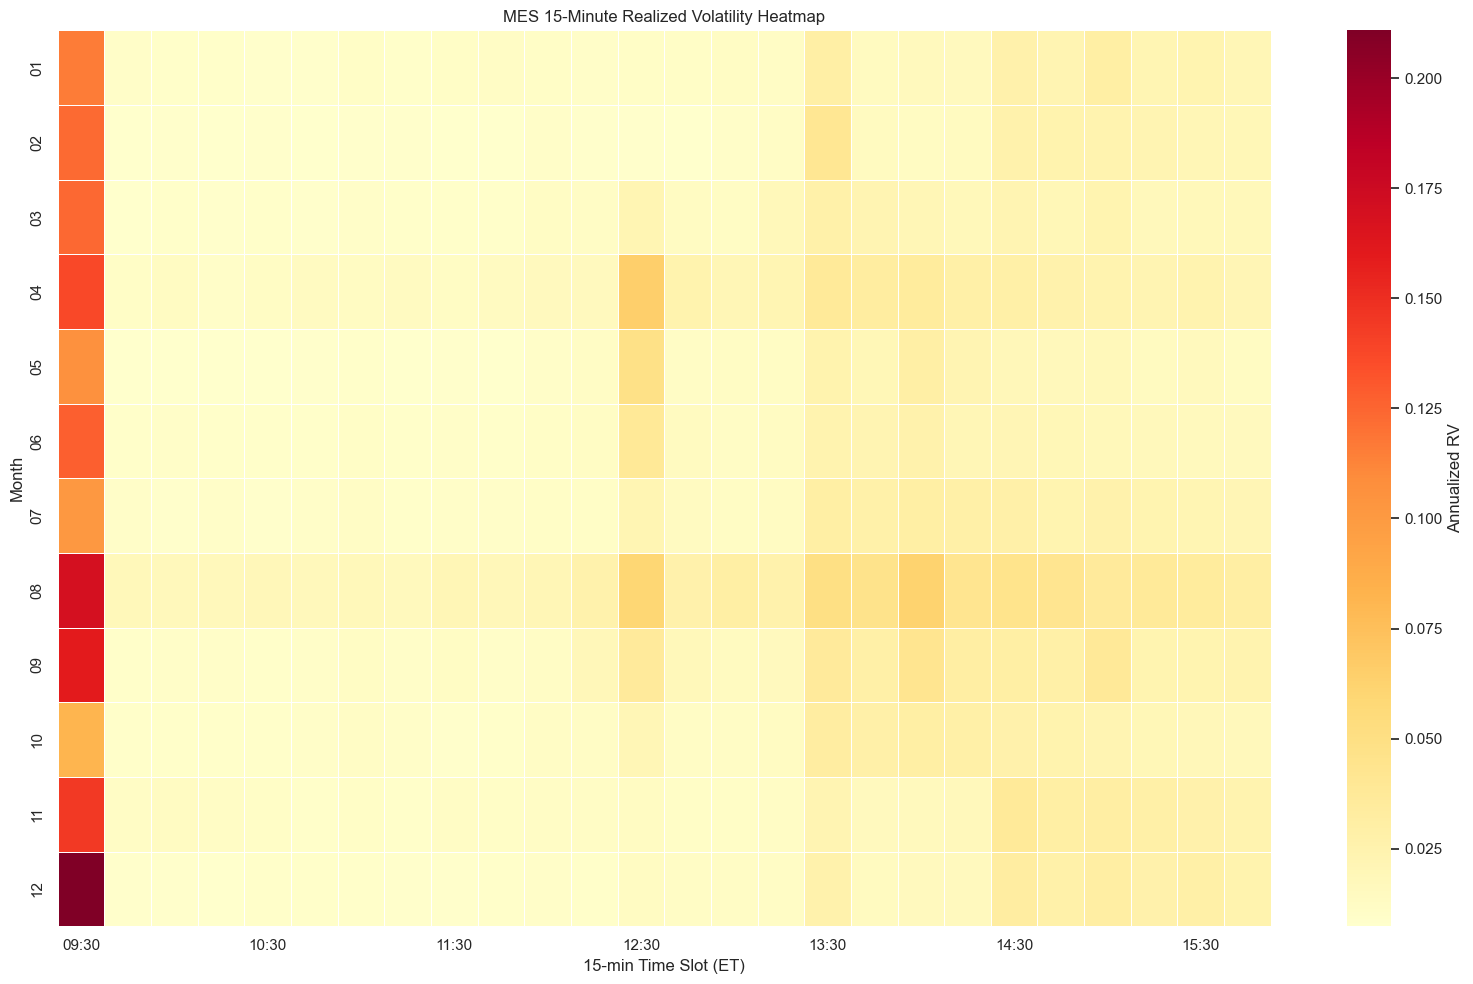

Session average RV: 0.0226
Time slots: 26, Months: 12


In [2]:
heatmap = compute_realized_vol_heatmap(df_1s, window_minutes=15)

# Build matrix for seaborn
vol_array = np.array(heatmap.vol_matrix)
month_labels = [f"{m:02d}" for m in heatmap.months]

# Show every 4th slot label to avoid crowding
slot_labels = [s if i % 4 == 0 else "" for i, s in enumerate(heatmap.time_slots)]

fig, ax = plt.subplots(figsize=(16, 4 + len(heatmap.months) * 0.5))
sns.heatmap(
    vol_array,
    xticklabels=slot_labels,
    yticklabels=month_labels,
    cmap="YlOrRd",
    ax=ax,
    cbar_kws={"label": "Annualized RV"},
    linewidths=0.5,
)
ax.set_xlabel("15-min Time Slot (ET)")
ax.set_ylabel("Month")
ax.set_title("MES 15-Minute Realized Volatility Heatmap")

plt.tight_layout()
plt.savefig("../docs/phase2/vol_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Session average RV: {heatmap.session_avg:.4f}")
print(f"Time slots: {len(heatmap.time_slots)}, Months: {len(heatmap.months)}")

## 2. Dead Zone Identification

Average vol curve by time slot with dead zone shading. The dead zone is where vol drops below session_avg / 1.5.

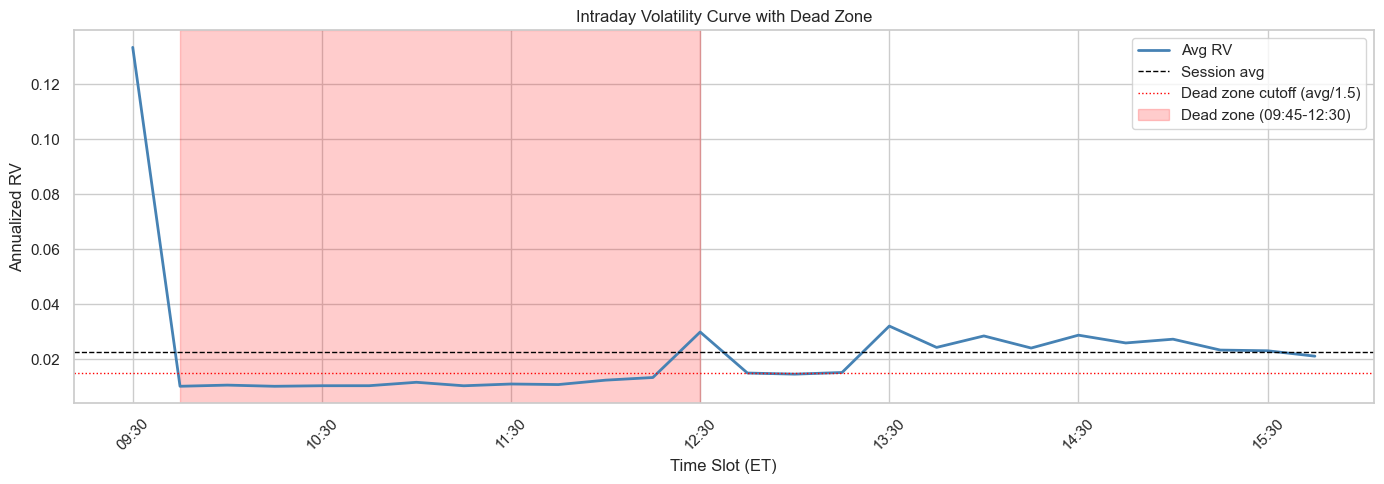


U-Shape Metrics:
  Open vol:    0.0411
  Midday vol:  0.0152
  Close vol:   0.0237
  U-ratio:     2.13x

Dead Zone: 09:45 – 12:30 (confidence: 89%)


In [3]:
dead_zone = identify_dead_zone(heatmap, threshold=1.5)
u_shape = compute_u_shape_metrics(heatmap)

# Average vol across months for each slot
avg_vol = np.mean(vol_array, axis=0)
cutoff = heatmap.session_avg / 1.5

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(heatmap.time_slots))

ax.plot(x, avg_vol, color="steelblue", linewidth=2, label="Avg RV")
ax.axhline(y=heatmap.session_avg, color="black", linestyle="--", linewidth=1, label="Session avg")
ax.axhline(y=cutoff, color="red", linestyle=":", linewidth=1, label=f"Dead zone cutoff (avg/1.5)")

# Shade dead zone
if dead_zone:
    dz_start_idx = heatmap.time_slots.index(dead_zone.start_time)
    dz_end_idx = heatmap.time_slots.index(dead_zone.end_time) if dead_zone.end_time in heatmap.time_slots else len(heatmap.time_slots)
    ax.axvspan(dz_start_idx, dz_end_idx, alpha=0.2, color="red", label=f"Dead zone ({dead_zone.start_time}-{dead_zone.end_time})")

ax.set_xticks([i for i in x if i % 4 == 0])
ax.set_xticklabels([heatmap.time_slots[i] for i in x if i % 4 == 0], rotation=45)
ax.set_xlabel("Time Slot (ET)")
ax.set_ylabel("Annualized RV")
ax.set_title("Intraday Volatility Curve with Dead Zone")
ax.legend()

plt.tight_layout()
plt.savefig("../docs/phase2/dead_zone.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nU-Shape Metrics:")
print(f"  Open vol:    {u_shape.open_vol:.4f}")
print(f"  Midday vol:  {u_shape.midday_vol:.4f}")
print(f"  Close vol:   {u_shape.close_vol:.4f}")
print(f"  U-ratio:     {u_shape.u_shape_ratio:.2f}x")
if dead_zone:
    print(f"\nDead Zone: {dead_zone.start_time} – {dead_zone.end_time} (confidence: {dead_zone.confidence:.0%})")

## 3. Spread Cost Analysis

Spread (0.25 pts) as % of 15-min ATR by time slot. Shows why the dead zone kills P&L — spread eats a larger fraction of available range.

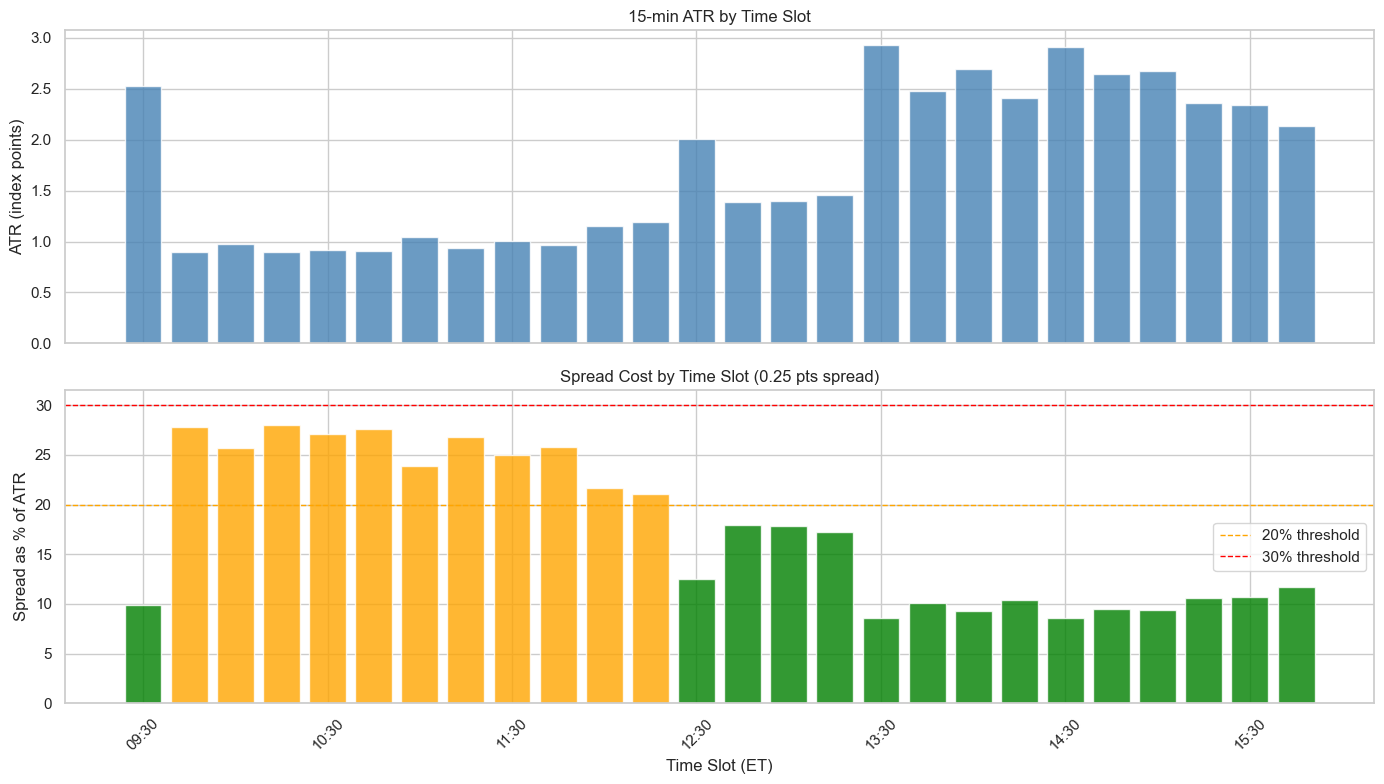


Top 5 worst slots (highest spread % of ATR):
  10:15: ATR=0.892, Spread=28.0% of ATR
  09:45: ATR=0.898, Spread=27.8% of ATR
  10:45: ATR=0.907, Spread=27.6% of ATR
  10:30: ATR=0.921, Spread=27.1% of ATR
  11:15: ATR=0.935, Spread=26.7% of ATR


In [4]:
spread = compute_spread_cost_by_slot(df_1s, window_minutes=15)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

x = range(len(spread.time_slots))

# ATR by slot
ax1.bar(x, spread.atr_values, color="steelblue", alpha=0.8)
ax1.set_ylabel("ATR (index points)")
ax1.set_title("15-min ATR by Time Slot")

# Spread % of ATR
colors = ["red" if p > 30 else "orange" if p > 20 else "green" for p in spread.spread_pct_of_atr]
ax2.bar(x, spread.spread_pct_of_atr, color=colors, alpha=0.8)
ax2.axhline(y=20, color="orange", linestyle="--", linewidth=1, label="20% threshold")
ax2.axhline(y=30, color="red", linestyle="--", linewidth=1, label="30% threshold")
ax2.set_ylabel("Spread as % of ATR")
ax2.set_title("Spread Cost by Time Slot (0.25 pts spread)")
ax2.legend()

ax2.set_xticks([i for i in x if i % 4 == 0])
ax2.set_xticklabels([spread.time_slots[i] for i in x if i % 4 == 0], rotation=45)
ax2.set_xlabel("Time Slot (ET)")

plt.tight_layout()
plt.savefig("../docs/phase2/spread_cost.png", dpi=150, bbox_inches="tight")
plt.show()

# Print worst slots
print("\nTop 5 worst slots (highest spread % of ATR):")
sorted_slots = sorted(zip(spread.time_slots, spread.atr_values, spread.spread_pct_of_atr),
                      key=lambda x: x[2], reverse=True)
for slot, atr, pct in sorted_slots[:5]:
    if atr > 0:
        print(f"  {slot}: ATR={atr:.3f}, Spread={pct:.1f}% of ATR")

## 4. Volume Profile (Sample Day)

Horizontal volume bars at each price level for a sample trading day, with POC, VAH, and VAL marked.

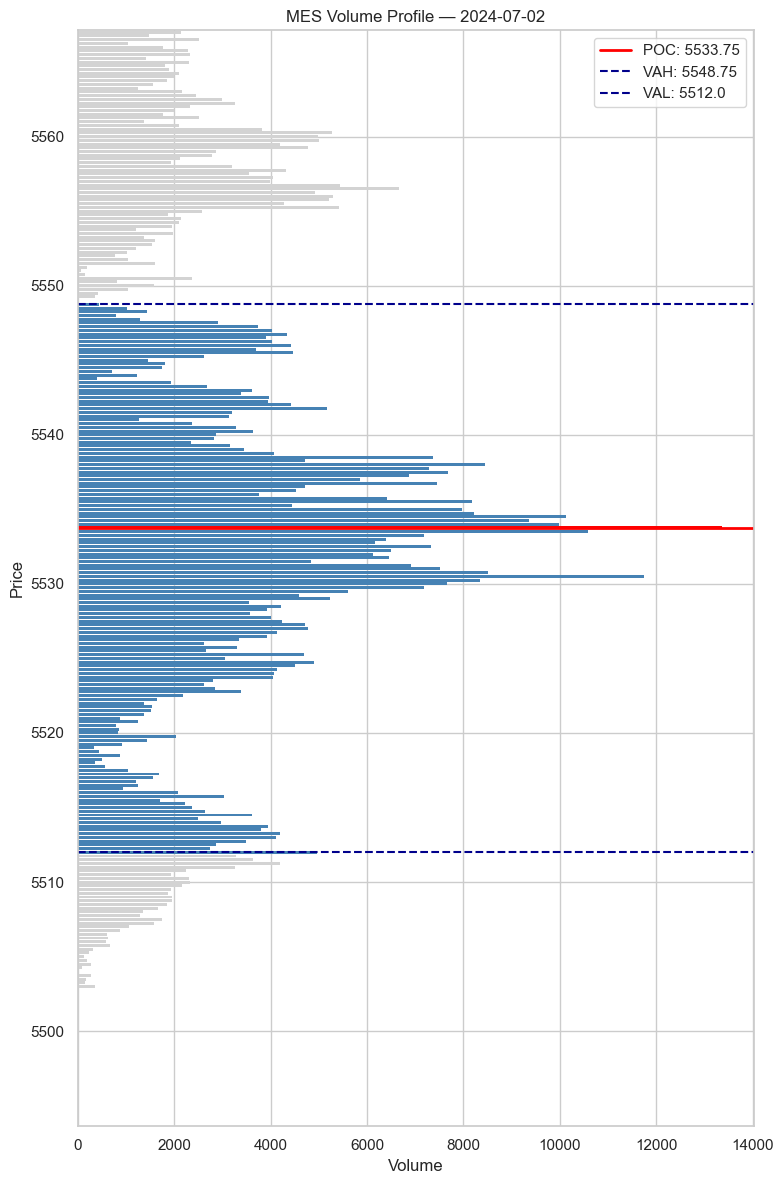

Date: 2024-07-02
POC:  5533.75
VAH:  5548.75
VAL:  5512.0
Value area width: 36.75 points


In [5]:
profiles = build_daily_profiles(df_1s, tick_size=0.25)

if profiles:
    # Pick a day near the middle of the dataset
    sample = profiles[len(profiles) // 2]

    fig, ax = plt.subplots(figsize=(8, 12))

    prices = np.array(sample.price_levels)
    vols = np.array(sample.volumes)

    # Color bars: POC=red, value area=blue, outside=gray
    colors = []
    for p in prices:
        if p == sample.poc:
            colors.append("red")
        elif sample.val <= p <= sample.vah:
            colors.append("steelblue")
        else:
            colors.append("lightgray")

    ax.barh(prices, vols, height=0.20, color=colors, edgecolor="none")

    # Mark POC, VAH, VAL
    ax.axhline(y=sample.poc, color="red", linewidth=2, linestyle="-", label=f"POC: {sample.poc}")
    ax.axhline(y=sample.vah, color="darkblue", linewidth=1.5, linestyle="--", label=f"VAH: {sample.vah}")
    ax.axhline(y=sample.val, color="darkblue", linewidth=1.5, linestyle="--", label=f"VAL: {sample.val}")

    ax.set_xlabel("Volume")
    ax.set_ylabel("Price")
    ax.set_title(f"MES Volume Profile — {sample.date}")
    ax.legend(loc="upper right")

    # Zoom to value area ± some padding
    price_range = sample.vah - sample.val
    ax.set_ylim(sample.val - price_range * 0.5, sample.vah + price_range * 0.5)

    plt.tight_layout()
    plt.savefig("../docs/phase2/volume_profile.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Date: {sample.date}")
    print(f"POC:  {sample.poc}")
    print(f"VAH:  {sample.vah}")
    print(f"VAL:  {sample.val}")
    print(f"Value area width: {sample.vah - sample.val:.2f} points")
else:
    print("No profiles built — check data.")

## 5. Event Day Comparison

Overlay FOMC day vol curves vs normal day vol curves to see how macro events distort the U-shape.

FOMC days: 305,384 bars across 8 days
Normal days: 10,109,474 bars


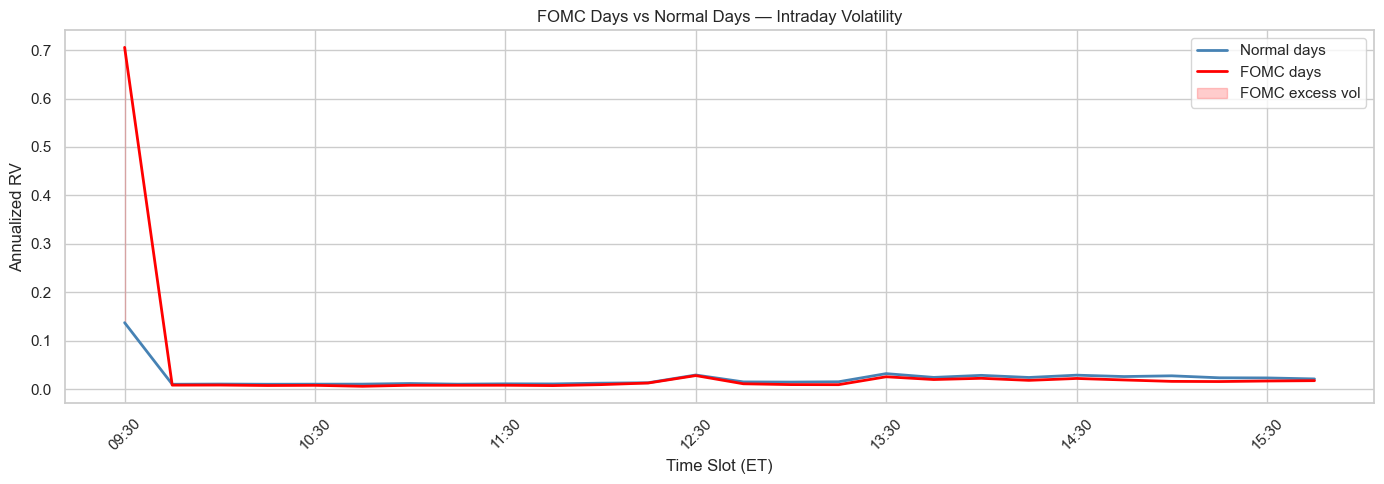


FOMC avg RV: 0.0403
Normal avg RV: 0.0227
FOMC premium: 1.77x


In [6]:
from src.analysis.intraday_profile import get_event_days

events = get_event_days(2024)
fomc_dates = {e.date for e in events if e.event_type == "FOMC"}

# Split data into FOMC days and normal days
df_with_date = df_1s.with_columns(pl.col("timestamp").dt.date().alias("trade_date"))
fomc_date_list = list(fomc_dates)

df_fomc = df_with_date.filter(pl.col("trade_date").is_in(fomc_date_list))
df_normal = df_with_date.filter(~pl.col("trade_date").is_in(fomc_date_list))

print(f"FOMC days: {len(df_fomc):,} bars across {len(fomc_dates)} days")
print(f"Normal days: {len(df_normal):,} bars")

# Compute heatmaps for both
if len(df_fomc) > 1000 and len(df_normal) > 1000:
    hm_fomc = compute_realized_vol_heatmap(df_fomc, window_minutes=15)
    hm_normal = compute_realized_vol_heatmap(df_normal, window_minutes=15)

    avg_fomc = np.mean(np.array(hm_fomc.vol_matrix), axis=0)
    avg_normal = np.mean(np.array(hm_normal.vol_matrix), axis=0)

    fig, ax = plt.subplots(figsize=(14, 5))
    x = range(len(hm_normal.time_slots))

    ax.plot(x, avg_normal, color="steelblue", linewidth=2, label="Normal days")
    ax.plot(x, avg_fomc, color="red", linewidth=2, label="FOMC days")
    ax.fill_between(x, avg_normal, avg_fomc, where=(np.array(avg_fomc) > np.array(avg_normal)),
                    alpha=0.2, color="red", label="FOMC excess vol")

    ax.set_xticks([i for i in x if i % 4 == 0])
    ax.set_xticklabels([hm_normal.time_slots[i] for i in x if i % 4 == 0], rotation=45)
    ax.set_xlabel("Time Slot (ET)")
    ax.set_ylabel("Annualized RV")
    ax.set_title("FOMC Days vs Normal Days — Intraday Volatility")
    ax.legend()

    plt.tight_layout()
    plt.savefig("../docs/phase2/event_day_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()

    # FOMC announcement is typically at 14:00 ET
    print(f"\nFOMC avg RV: {hm_fomc.session_avg:.4f}")
    print(f"Normal avg RV: {hm_normal.session_avg:.4f}")
    print(f"FOMC premium: {hm_fomc.session_avg / hm_normal.session_avg:.2f}x")
else:
    print("Insufficient data for FOMC comparison.")

## 6. Findings Table & Strategy Implications

Summary of dead zone times, recommended trading windows, and event day policy.

In [7]:
print("=" * 70)
print("FINDINGS: INTRADAY VOLATILITY & VOLUME PROFILE")
print("=" * 70)

print(f"\n1. U-SHAPE PATTERN")
print(f"   Open vol (9:30-10:30):    {u_shape.open_vol:.4f}")
print(f"   Midday vol (11:30-13:30): {u_shape.midday_vol:.4f}")
print(f"   Close vol (15:00-16:00):  {u_shape.close_vol:.4f}")
print(f"   U-shape ratio:            {u_shape.u_shape_ratio:.2f}x")

print(f"\n2. DEAD ZONE")
if dead_zone:
    print(f"   Window:     {dead_zone.start_time} – {dead_zone.end_time} ET")
    print(f"   Confidence: {dead_zone.confidence:.0%} of months")
    print(f"   Impact:     Spread eats {1/dead_zone.threshold_multiplier:.0%}+ more of available range")
else:
    print(f"   Not identified at threshold 1.5x")

print(f"\n3. RECOMMENDED TRADING WINDOWS")
print(f"   PRIMARY:   9:30 – 11:00 ET  (opening momentum + reversion)")
print(f"   SECONDARY: 14:00 – 15:45 ET (closing activity)")
if dead_zone:
    print(f"   AVOID:     {dead_zone.start_time} – {dead_zone.end_time} ET (dead zone)")

print(f"\n4. EVENT DAY POLICY")
print(f"   FOMC days: Reduce size pre-announcement (14:00 ET), widen stops post-announcement")
print(f"   NFP days:  Avoid first 30 min (8:30-9:00 pre-market), normal after 10:00")
print(f"   CPI days:  Same as NFP — volatility spike at 8:30, normalizes by 10:00")

print(f"\n5. PHASE 3 INTEGRATION")
print(f"   - Session filter: only trade during recommended windows")
print(f"   - Spread guard: reject signals when spread > 25% of target")
print(f"   - Event calendar: check get_event_days() at session open")
print(f"   - Volume profile: use POC as intraday S/R level for VWAP reversion")

print(f"\n{'=' * 70}")
print("Save these findings — they define the entry filters for Phase 3 strategies.")

FINDINGS: INTRADAY VOLATILITY & VOLUME PROFILE

1. U-SHAPE PATTERN
   Open vol (9:30-10:30):    0.0411
   Midday vol (11:30-13:30): 0.0152
   Close vol (15:00-16:00):  0.0237
   U-shape ratio:            2.13x

2. DEAD ZONE
   Window:     09:45 – 12:30 ET
   Confidence: 89% of months
   Impact:     Spread eats 67%+ more of available range

3. RECOMMENDED TRADING WINDOWS
   PRIMARY:   9:30 – 11:00 ET  (opening momentum + reversion)
   SECONDARY: 14:00 – 15:45 ET (closing activity)
   AVOID:     09:45 – 12:30 ET (dead zone)

4. EVENT DAY POLICY
   FOMC days: Reduce size pre-announcement (14:00 ET), widen stops post-announcement
   NFP days:  Avoid first 30 min (8:30-9:00 pre-market), normal after 10:00
   CPI days:  Same as NFP — volatility spike at 8:30, normalizes by 10:00

5. PHASE 3 INTEGRATION
   - Session filter: only trade during recommended windows
   - Spread guard: reject signals when spread > 25% of target
   - Event calendar: check get_event_days() at session open
   - Volume